In [50]:
import numpy as np
import pandas as pd
df = pd.read_csv("/content/Crop_recommendation.csv")

In [28]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [51]:
display(df['label'].nunique())

22

In [52]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label,label_encoded
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,20


In [53]:
df = df.drop('label', axis=1)
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label_encoded
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [54]:
display(df['label_encoded'].nunique())

22

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features = df.drop('label_encoded', axis=1)
scaled_features = scaler.fit_transform(features)

# Create a new DataFrame with scaled features and the target variable
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df['label_encoded'] = df['label_encoded']

display(scaled_df.head())

,N,P,K,temperature,humidity,ph,rainfall,label_encoded
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361,20
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058,20
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066,20
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048,20
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373,20


In [56]:
from sklearn.model_selection import train_test_split

X = scaled_df.drop('label_encoded', axis=1)
y = scaled_df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

display(X_train.head())
display(y_train.head())

,N,P,K,temperature,humidity,ph,rainfall
208,-0.231700,0.261907,0.530269,-1.469033,-2.362105,0.699299,-0.393363
1641,-1.369636,-0.920686,-0.654649,-0.602379,0.983573,1.459427,0.116386
881,-1.125793,0.079970,-0.615152,0.102880,-0.211551,-0.268225,-1.037036
720,0.201799,0.534813,-0.654649,0.436472,-0.175014,0.581269,-0.536007
1017,1.583578,0.777396,-0.062190,0.405184,0.368558,0.026616,0.094656


,label_encoded
208,3
1641,16
881,10
720,2
1017,1


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Initialize the models
lr_model = LogisticRegression(random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# Train the models
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Evaluate the models
lr_accuracy = accuracy_score(y_test, lr_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

lr_f1 = f1_score(y_test, lr_pred, average='weighted')
dt_f1 = f1_score(y_test, dt_pred, average='weighted')
xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print("Logistic Regression Accuracy:", lr_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("XGBoost Accuracy:", xgb_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

print("\nLogistic Regression F1 Score:", lr_f1)
print("Decision Tree F1 Score:", dt_f1)
print("XGBoost F1 Score:", xgb_f1)
print("Random Forest F1 Score:", rf_f1)

Logistic Regression Accuracy: 0.9590909090909091
Decision Tree Accuracy: 0.9852272727272727
XGBoost Accuracy: 0.9818181818181818
Random Forest Accuracy: 0.9920454545454546

Logistic Regression F1 Score: 0.9589511227343629
Decision Tree F1 Score: 0.9852255394304741
XGBoost F1 Score: 0.9818509892396267
Random Forest F1 Score: 0.9919784946236558


In [58]:
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Define base models
estimators = [
    ('lr', lr_model),
    ('dt', dt_model),
    ('xgb', xgb_model),
    ('rf', rf_model)
]

# Define meta-model (using Logistic Regression as an example)
meta_model = LogisticRegression()

# Create the stacking classifier
stacked_model = StackingClassifier(estimators=estimators, final_estimator=meta_model, cv=5)

# Train the stacked model
stacked_model.fit(X_train, y_train)

# Make predictions with the stacked model
stacked_pred = stacked_model.predict(X_test)

# Evaluate the stacked model
stacked_accuracy = accuracy_score(y_test, stacked_pred)
stacked_f1 = f1_score(y_test, stacked_pred, average='weighted')

print("Stacked Model Accuracy:", stacked_accuracy)
print("Stacked Model F1 Score:", stacked_f1)

Stacked Model Accuracy: 0.9920454545454546
Stacked Model F1 Score: 0.9919784946236558


In [59]:
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from xgboost import XGBClassifier
# from sklearn.ensemble import RandomForestClassifier

# # Define parameter grids for each model
# lr_param_grid = {
#     'C': [0.001, 0.01, 0.1, 1, 10, 100],
#     'penalty': ['l2'] # Removed 'l1' as it's not supported by the default solver
# }

# dt_param_grid = {
#     'criterion': ['gini', 'entropy'],
#     'max_depth': [None, 10, 20, 30, 40, 50],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# xgb_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'max_depth': [3, 5, 7],
#     'subsample': [0.7, 0.8, 0.9]
# }

# rf_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'criterion': ['gini', 'entropy'],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

In [60]:
# # Perform GridSearchCV for each model
# grid_search_lr = GridSearchCV(lr_model, lr_param_grid, cv=2, scoring='accuracy')
# grid_search_lr.fit(X_train, y_train)
# best_lr_model = grid_search_lr.best_estimator_

# grid_search_dt = GridSearchCV(dt_model, dt_param_grid, cv=2, scoring='accuracy')
# grid_search_dt.fit(X_train, y_train)
# best_dt_model = grid_search_dt.best_estimator_

# grid_search_xgb = GridSearchCV(xgb_model, xgb_param_grid, cv=2, scoring='accuracy')
# grid_search_xgb.fit(X_train, y_train)
# best_xgb_model = grid_search_xgb.best_estimator_

# grid_search_rf = GridSearchCV(rf_model, rf_param_grid, cv=2, scoring='accuracy')
# grid_search_rf.fit(X_train, y_train)
# best_rf_model = grid_search_rf.best_estimator_

# print("Best parameters found:")
# print("Logistic Regression:", grid_search_lr.best_params_)
# print("Decision Tree:", grid_search_dt.best_params_)
# print("XGBoost:", grid_search_xgb.best_params_)
# print("Random Forest:", grid_search_rf.best_params_)

In [61]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

# Compare Training vs Test Performance
print("Training Accuracy:")
print("Logistic Regression:", lr_model.score(X_train, y_train))
print("Decision Tree:", dt_model.score(X_train, y_train))
print("XGBoost:", xgb_model.score(X_train, y_train))
print("Random Forest:", rf_model.score(X_train, y_train))
print("Stacked Model:", stacked_model.score(X_train, y_train))

print("\nTest Accuracy:")
print("Logistic Regression:", lr_accuracy)
print("Decision Tree:", dt_accuracy)
print("XGBoost:", xgb_accuracy)
print("Random Forest:", rf_accuracy)
print("Stacked Model:", stacked_accuracy)

# Use Cross-Validation (K-Fold)
k = 5 # Number of folds
lr_cv_scores = cross_val_score(lr_model, X, y, cv=k, scoring='accuracy')
dt_cv_scores = cross_val_score(dt_model, X, y, cv=k, scoring='accuracy')
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=k, scoring='accuracy')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=k, scoring='accuracy')
stacked_cv_scores = cross_val_score(stacked_model, X, y, cv=k, scoring='accuracy')

print("\nK-Fold Cross-Validation Accuracy (Mean +/- Std Dev):")
print("Logistic Regression: %0.2f +/- %0.2f" % (lr_cv_scores.mean(), lr_cv_scores.std()))
print("Decision Tree: %0.2f +/- %0.2f" % (dt_cv_scores.mean(), dt_cv_scores.std()))
print("XGBoost: %0.2f +/- %0.2f" % (xgb_cv_scores.mean(), xgb_cv_scores.std()))
print("Random Forest: %0.2f +/- %0.2f" % (rf_cv_scores.mean(), rf_cv_scores.std()))
print("Stacked Model: %0.4f +/- %0.4f" % (stacked_cv_scores.mean(), stacked_cv_scores.std()))

# Check Per-Class Metrics for stacked data
print("\nClassification Report for Stacked Model (Test Set):")
print(classification_report(y_test, stacked_pred))

Training Accuracy:
Logistic Regression: 0.9803030303030303
Decision Tree: 1.0
XGBoost: 1.0
Random Forest: 1.0
Stacked Model: 1.0

Test Accuracy:
Logistic Regression: 0.9590909090909091
Decision Tree: 0.9852272727272727
XGBoost: 0.9818181818181818
Random Forest: 0.9920454545454546
Stacked Model: 0.9920454545454546

K-Fold Cross-Validation Accuracy (Mean +/- Std Dev):
Logistic Regression: 0.97 +/- 0.01
Decision Tree: 0.99 +/- 0.00
XGBoost: 0.99 +/- 0.00
Random Forest: 0.99 +/- 0.00
Stacked Model: 0.99 +/- 0.00

Classification Report for Stacked Model (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        37
           3       1.00      1.00      1.00        47
           4       1.00      1.00      1.00        43
           5       1.00      1.00      1.00        39
           6       1.00      1.00      1.00        40


In [63]:
print("\nK-Fold Cross-Validation Accuracy (Mean +/- Std Dev):")
print("Logistic Regression: %0.2f +/- %0.2f" % (lr_cv_scores.mean(), lr_cv_scores.std()))
print("Decision Tree: %0.2f +/- %0.2f" % (dt_cv_scores.mean(), dt_cv_scores.std()))
print("XGBoost: %0.2f +/- %0.2f" % (xgb_cv_scores.mean(), xgb_cv_scores.std()))
print("Random Forest: %0.2f +/- %0.2f" % (rf_cv_scores.mean(), rf_cv_scores.std()))
print("Stacked Model: %0.4f +/- %0.4f" % (stacked_cv_scores.mean(), stacked_cv_scores.std()))

# Check Per-Class Metrics for stacked data
print("\nClassification Report for Stacked Model (Test Set):")
print(classification_report(y_test, stacked_pred))


K-Fold Cross-Validation Accuracy (Mean +/- Std Dev):
Logistic Regression: 0.97 +/- 0.01
Decision Tree: 0.99 +/- 0.00
XGBoost: 0.99 +/- 0.00
Random Forest: 0.99 +/- 0.00
Stacked Model: 0.9950 +/- 0.0039

Classification Report for Stacked Model (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        37
           3       1.00      1.00      1.00        47
           4       1.00      1.00      1.00        43
           5       1.00      1.00      1.00        39
           6       1.00      1.00      1.00        40
           7       1.00      1.00      1.00        36
           8       0.89      0.98      0.93        43
           9       1.00      1.00      1.00        45
          10       0.97      1.00      0.99        37
          11       1.00      1.00      1.00        37
          12       1.00      1.00      1.

**We cant use just correlations because here For example, if "rice"=0 and "coffee"=21, the fact that correlation with "humidity" is 0.19 doesn’t mean coffee or rice are more correlated — it just reflects a trend with the arbitrary numeric labels.**

**So, correlation with label_encoded is misleading in multiclass problems.**

Correlation with label_encoded:
label_encoded    1.000000
humidity         0.193911
temperature      0.113606
rainfall         0.045611
ph              -0.012253
N               -0.031130
K               -0.346417
P               -0.491006
Name: label_encoded, dtype: float64


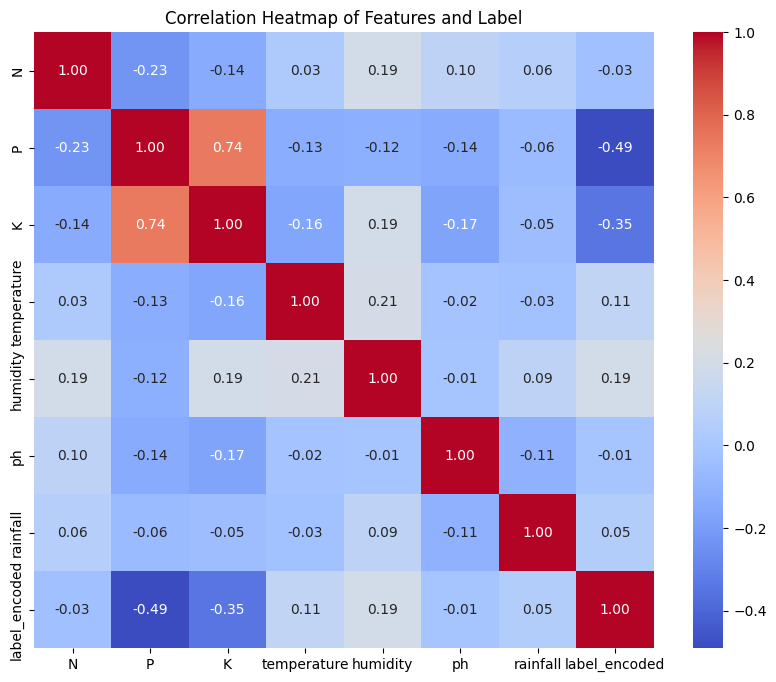

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlation with the target variable ('label_encoded')
print("Correlation with label_encoded:")
print(correlation_matrix['label_encoded'].sort_values(ascending=False))

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features and Label')
plt.show()

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646


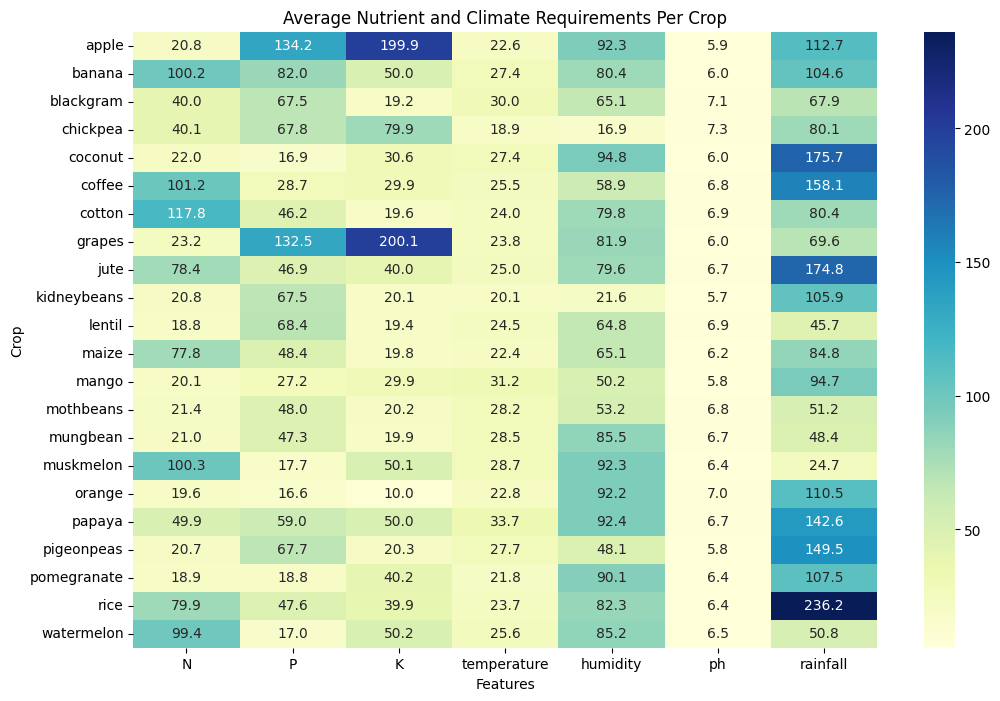

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
df1 = pd.read_csv("/content/Crop_recommendation.csv")

# Compute mean feature values for each crop
crop_features = df1.groupby("label")[["N","P","K","temperature","humidity","ph","rainfall"]].mean()
display(crop_features.head())

# Plot the heatmap of average requirements
plt.figure(figsize=(12, 8))
sns.heatmap(crop_features, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Average Nutrient and Climate Requirements Per Crop')
plt.xlabel('Features')
plt.ylabel('Crop')
plt.show()

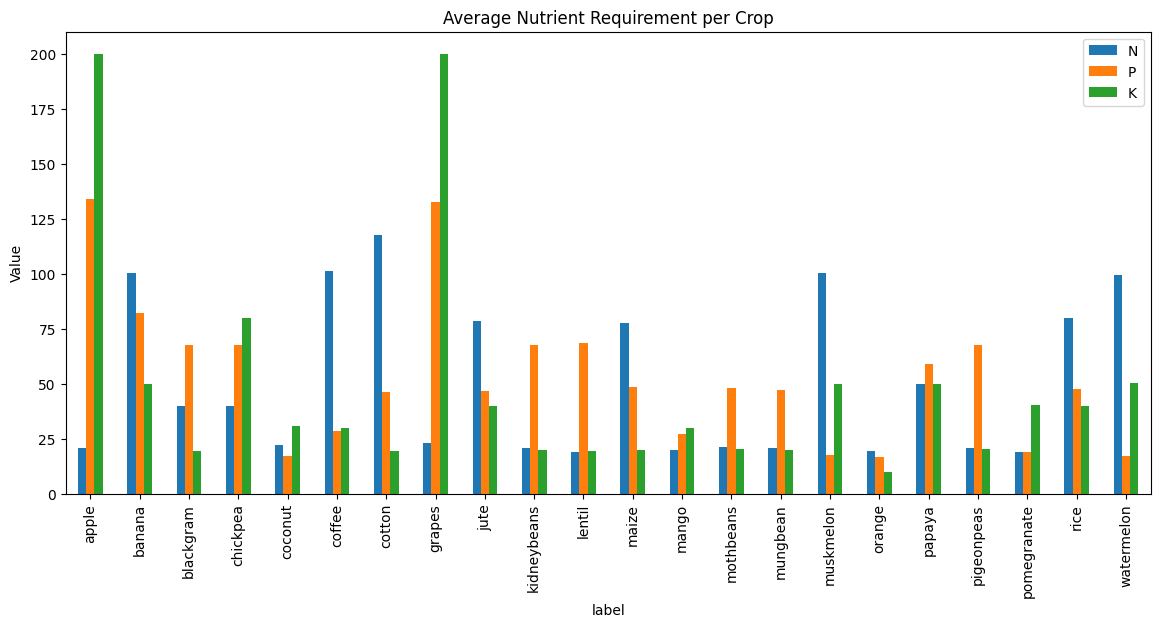

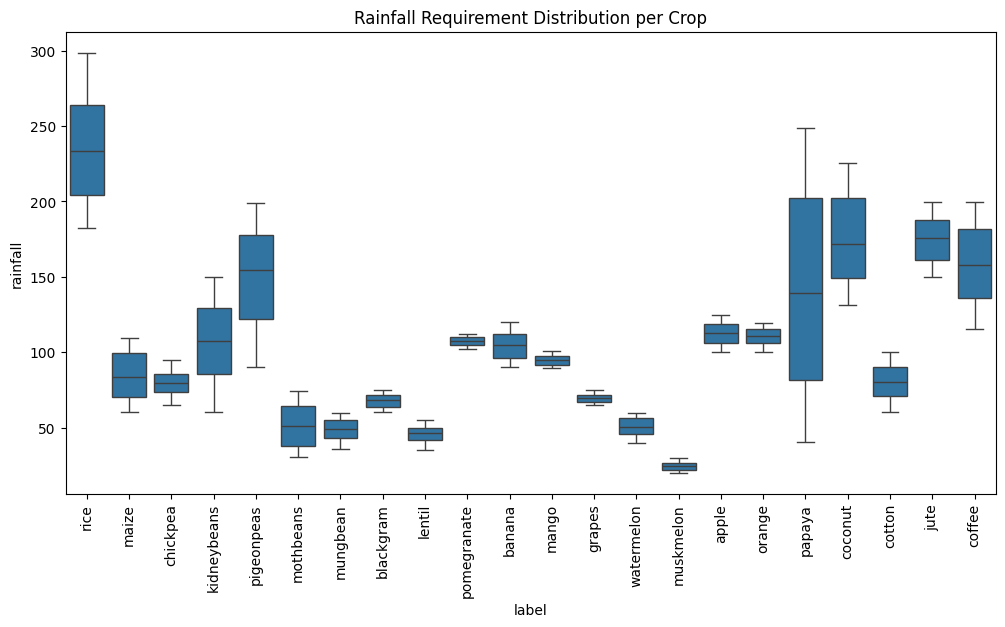

In [73]:
# Bar Plots for Each Feature
crop_features[["N","P","K"]].plot(kind="bar", figsize=(14,6))
plt.title("Average Nutrient Requirement per Crop")
plt.ylabel("Value")
plt.show()

# Boxplots for Feature Distributions
plt.figure(figsize=(12,6))
sns.boxplot(x="label", y="rainfall", data=df1)
plt.xticks(rotation=90)
plt.title("Rainfall Requirement Distribution per Crop")
plt.show()

In [62]:
import pickle

# Save the stacked model to a pickle file
filename = 'stacked_model.pkl'
pickle.dump(stacked_model, open(filename, 'wb'))

print(f"Stacked model saved to {filename}")

Stacked model saved to stacked_model.pkl


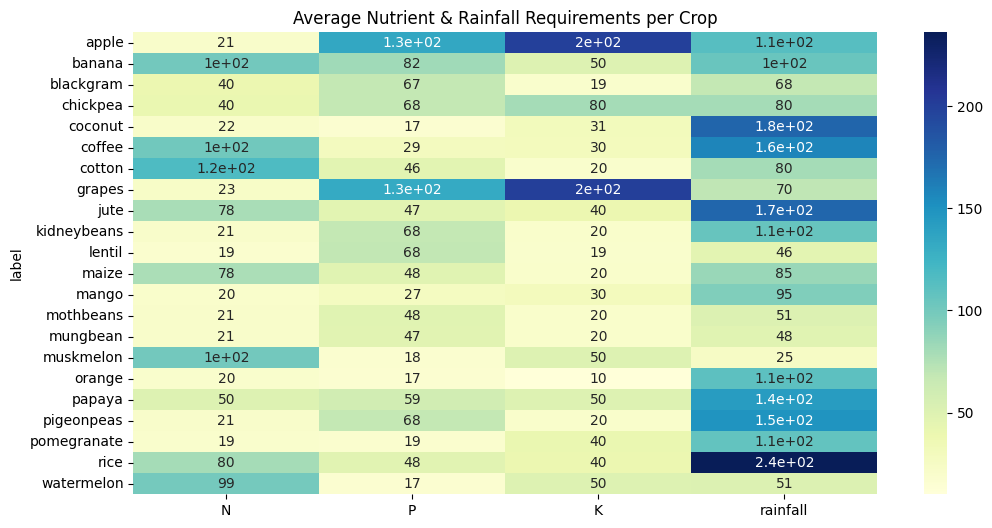

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df1 = pd.read_csv("/content/Crop_recommendation.csv")

crop_features = df1.groupby("label")[["N","P","K","rainfall"]].mean()
# Heatmap for nutrient & rainfall needs
plt.figure(figsize=(12,6))
sns.heatmap(crop_features, annot=True, cmap="YlGnBu")
plt.title("Average Nutrient & Rainfall Requirements per Crop")
plt.show()

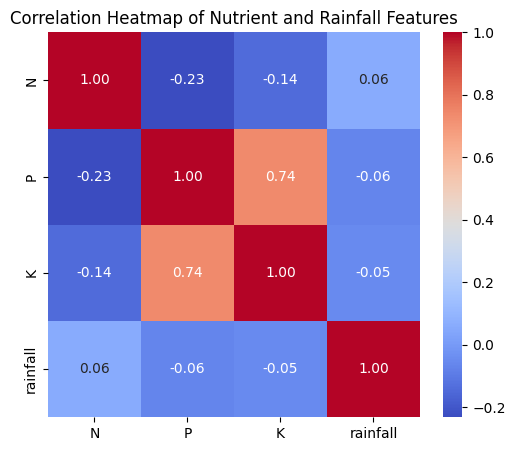

In [79]:
# Select only the nutrient and rainfall columns
nutrient_rainfall_df = df[['N', 'P', 'K', 'rainfall']]

# Calculate the correlation matrix for these features
nutrient_rainfall_correlation = nutrient_rainfall_df.corr()

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(nutrient_rainfall_correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Nutrient and Rainfall Features')
plt.show()